# Plot Basis States Comparison

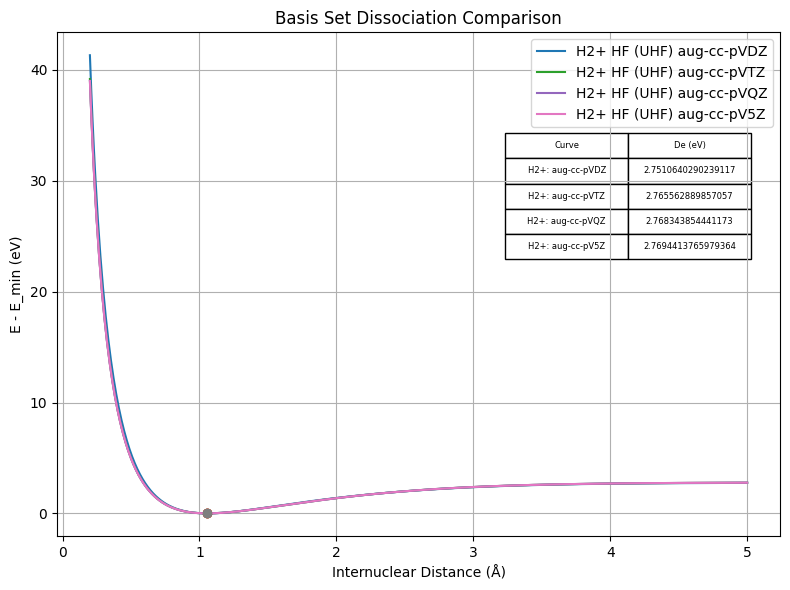

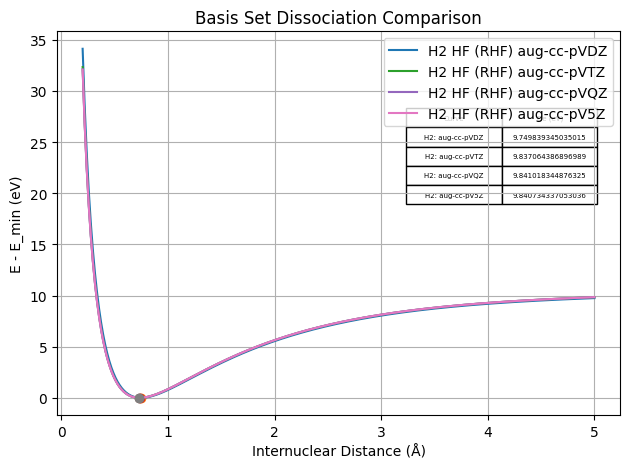

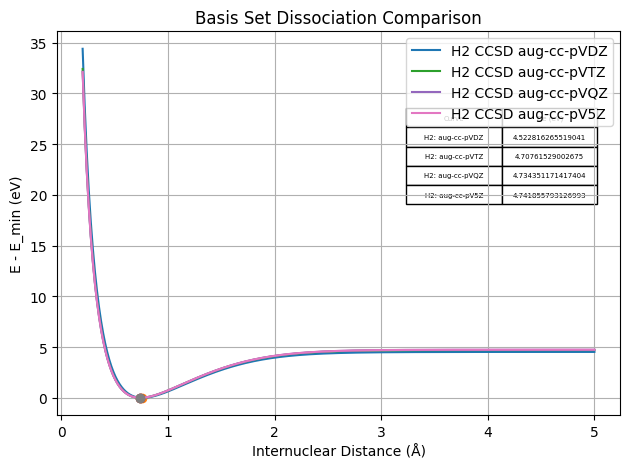

In [4]:
import csv
import numpy as np
import matplotlib.pyplot as plt


basis_sets = ["aug-cc-pVDZ", "aug-cc-pVTZ", "aug-cc-pVQZ", "aug-cc-pV5Z"]
hartree_to_ev = 27.211396

def read_two_col_csv(path):
    R, E = [], []
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        _ = next(reader)  # header
        for row in reader:
            if not row:
                continue
            R.append(float(row[0]))
            E.append(float(row[1]))
    return np.array(R), np.array(E)


E_eV_h2p_hf = []
R_A_h2p_hf = []

E_eV_h2_hf = []
R_A_h2_hf = []

E_eV_h2_ccsd = []
R_A_h2_ccsd = []

minimum_h2p_hf = []
minimum_h2_hf = []
minimum_h2_ccsd = []


for basis in basis_sets:

    # ---- Load data (filenames must match your outputs) ----
    R_h2p_hf,   E_h2p_hf   = read_two_col_csv(f"h2plus_hf_pec_{basis}.csv")
    
    R_h2_hf,   E_h2_hf   = read_two_col_csv(f"h2_hf_pec_{basis}.csv")

    R_h2_ccsd,   E_h2_ccsd   = read_two_col_csv(f"h2_ccsd_pec_{basis}.csv")

    # ---- Shift each curve so its own minimum is 0 (nice for PEC comparison) ----
    E_h2p_hf_s   = E_h2p_hf   - E_h2p_hf.min()
    E_h2p_hf_eV   = E_h2p_hf_s   * hartree_to_ev

    E_h2_hf_s   = E_h2_hf   - E_h2_hf.min()
    E_h2_hf_eV   = E_h2_hf_s   * hartree_to_ev

    E_h2_ccsd_s   = E_h2_ccsd   - E_h2_ccsd.min()
    E_h2_ccsd_eV   = E_h2_ccsd_s   * hartree_to_ev

    min_idx_h2p_hf = np.argmin(E_h2p_hf_s)
    
    min_idx_h2_hf = np.argmin(E_h2_hf_s)

    min_idx_h2_ccsd = np.argmin(E_h2_ccsd_s)

    E_eV_h2p_hf.append(E_h2p_hf_eV)
    R_A_h2p_hf.append(R_h2p_hf)
    minimum_h2p_hf.append(min_idx_h2p_hf)

    E_eV_h2_hf.append(E_h2_hf_eV)
    R_A_h2_hf.append(R_h2_hf)
    minimum_h2_hf.append(min_idx_h2_hf)

    E_eV_h2_ccsd.append(E_h2_ccsd_eV)
    R_A_h2_ccsd.append(R_h2_ccsd)
    minimum_h2_ccsd.append(min_idx_h2_ccsd)


# ---- Plot all three on one figure ----
plt.figure(figsize=(8,6))

# Plot smooth curves (no markers)

table_data = []

for i in range(len(E_eV_h2p_hf)):
    plt.plot(R_A_h2p_hf[i], E_eV_h2p_hf[i], linestyle="-", label=f"H2+ HF (UHF) {basis_sets[i]}")

    # --- Find and plot the minimum point for each curve ---
    plt.plot(R_A_h2p_hf[i][minimum_h2p_hf[i]], E_eV_h2p_hf[i][minimum_h2p_hf[i]], 'o')

    De_h2p_hf_eV = E_eV_h2p_hf[i][-1]

    #create table

    label_de = [f"H2+: {basis_sets[i]}", f"{De_h2p_hf_eV}"]
    table_data.append(label_de)

tbl = plt.table(
    cellText=table_data,
    colLabels=["Curve", "De (eV)"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.62, 0.55, 0.34, 0.25],  # [left, bottom, width, height] in axes fraction
)

# Labels
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("E - E_min (eV)")
plt.title("Basis Set Dissociation Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

table_data = []

for i in range(len(E_eV_h2_hf)):
    plt.plot(R_A_h2_hf[i], E_eV_h2_hf[i], linestyle="-", label=f"H2 HF (RHF) {basis_sets[i]}")

    # --- Find and plot the minimum point for each curve ---
    plt.plot(R_A_h2_hf[i][minimum_h2_hf[i]], E_eV_h2_hf[i][minimum_h2_hf[i]], 'o')

    De_h2p_hf_eV = E_eV_h2_hf[i][-1]

    #create table

    label_de = [f"H2: {basis_sets[i]}", f"{De_h2p_hf_eV}"]
    table_data.append(label_de)

tbl = plt.table(
    cellText=table_data,
    colLabels=["Curve", "De (eV)"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.62, 0.55, 0.34, 0.25],  # [left, bottom, width, height] in axes fraction
)

# Labels
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("E - E_min (eV)")
plt.title("Basis Set Dissociation Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

table_data = []

for i in range(len(E_eV_h2_ccsd)):
    plt.plot(R_A_h2_ccsd[i], E_eV_h2_ccsd[i], linestyle="-", label=f"H2 CCSD {basis_sets[i]}")

    # --- Find and plot the minimum point for each curve ---
    plt.plot(R_A_h2_ccsd[i][minimum_h2_ccsd[i]], E_eV_h2_ccsd[i][minimum_h2_ccsd[i]], 'o')

    De_h2p_ccsd_eV = E_eV_h2_ccsd[i][-1]

    #create table

    label_de = [f"H2: {basis_sets[i]}", f"{De_h2p_ccsd_eV}"]
    table_data.append(label_de)

tbl = plt.table(
    cellText=table_data,
    colLabels=["Curve", "De (eV)"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.62, 0.55, 0.34, 0.25],  # [left, bottom, width, height] in axes fraction
)

# Labels
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("E - E_min (eV)")
plt.title("Basis Set Dissociation Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()